In [ ]:
!pip install --upgrade scikit-learn xgboost
!pip install dask[dataframe]



INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 15.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import io
import math

# Read the uploaded CSV file directly into a DataFrame
matches = pd.read_csv("matches.csv")

# Clean column names and strip whitespace
matches.columns = matches.columns.str.strip()

# Process the 'date' column
if 'date' in matches.columns:
    matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Ensure 'date_ordinal' column is created early
matches['date_ordinal'] = matches['date'].apply(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Encode categorical variables for venue and opponent
matches['venue_code'] = matches['venue'].astype('category').cat.codes
matches['opp_code'] = matches['opponent'].astype('category').cat.codes

# Extract hour and create cyclical features
if 'time' in matches.columns:
    matches['hour'] = matches['time'].str.extract(r'(\d+)').astype(float)
    matches['hour_sin'] = np.sin(2 * np.pi * matches['hour'] / 24)
    matches['hour_cos'] = np.cos(2 * np.pi * matches['hour'] / 24)
else:
    matches['hour_sin'], matches['hour_cos'] = 0, 0

# Map days to numerical values
matches['day_code'] = matches['day'].map({"Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7})
matches['day_sin'] = np.sin(2 * np.pi * matches['day_code'] / 7)
matches['day_cos'] = np.cos(2 * np.pi * matches['day_code'] / 7)

# Create binary target (1 = Win, 0 = Loss/Draw)
matches['target'] = (matches['result'] == 'W').astype(int)

# Compute rolling averages (excluding current match)
def rolling_averages(group, cols, window=4):
    group = group.sort_values("round")
    return group.assign(**{f"{c}_rolling": group[c].rolling(window=window, closed="left").mean().fillna(0) for c in cols})

cols = ["gf", "ga", "sh", "sot", "xg", "xga", "poss","xa", "kp", "prgp", "prgc", "ppa", "tkl+int", "blocks", "touches",
        "Total_Passes_cmp", "Total_Passes_att"]

# 🔥 Fix: Ensure 'round' column exists before sorting
if 'round' not in matches.columns:
    print("⚠️ Warning: 'round' column not found! Checking for alternatives...")
    for col in matches.columns:
        if 'matchweek' in col.lower() or 'gameweek' in col.lower():
            matches.rename(columns={col: 'round'}, inplace=True)
            print(f"✅ Renamed '{col}' to 'round'.")
            break

# 🔥 Fix: If still missing, create a proxy
if 'round' not in matches.columns:
    matches['round'] = matches.groupby('season').cumcount() + 1
    print("✅ Created 'round' column as a proxy.")

matches_rolling = matches.groupby("team", group_keys=False)\
                         .apply(lambda x: rolling_averages(x, cols, window=4))

matches_rolling.reset_index(drop=True, inplace=True)

# 🔥 Fix: Ensure 'date_ordinal' exists before using it in groupby
if 'date_ordinal' not in matches_rolling.columns:
    matches_rolling['date_ordinal'] = matches_rolling['date'].apply(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# 🔥 Apply rolling averages correctly with `include_groups=False`
matches_rolling = matches_rolling.groupby('date_ordinal', group_keys=False, observed=True)\
                                 .apply(lambda x: rolling_averages(x, cols, window=4))

# ----- Compute Win and Non‑Win Streak Features Without Leakage -----
def compute_streaks(group):
    group = group.sort_values('round')
    win_streak = []
    nonwin_streak = []
    current_win, current_nonwin = 0, 0
    for _, row in group.iterrows():
        win_streak.append(current_win)
        nonwin_streak.append(current_nonwin)
        if row['target'] == 1:
            current_win += 1
            current_nonwin = 0
        else:
            current_nonwin += 1
            current_win = 0
    group['win_streak'] = win_streak
    group['nonwin_streak'] = nonwin_streak
    return group

matches_rolling = matches_rolling.groupby('team', group_keys=False).apply(compute_streaks)

# Compute lagged interaction features to avoid leakage
matches_rolling['win_xg_interaction'] = matches_rolling['win_streak'] * matches_rolling['xg_rolling'].shift(1).fillna(0)
matches_rolling['nonwin_xga_interaction'] = matches_rolling['nonwin_streak'] * matches_rolling['xga_rolling'].shift(1).fillna(0)

# ----- Add Date Feature -----
matches_rolling['date_ordinal'] = matches_rolling['date'].apply(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# Fix final DataFrame structure
matches_rolling = matches_rolling.loc[:, ~matches_rolling.columns.duplicated()]


# ... [rest of the code remains the same until the last section] ...
# ----- Advanced Feature Engineering -----
def add_advanced_features(df):
    d = df.copy()

    # Existing derived features
    d['low_ga_rolling'] = d['ga_rolling']  # Proxy for few goals conceded
    d['xg_diff_rolling'] = abs(d['xg_rolling'] - d['xga_rolling'])
    d['combined_xg_rolling'] = d['xg_rolling'] + d['xga_rolling']
    d['recent_form'] = d.groupby('team')['target']\
                        .transform(lambda s: s.rolling(window=4, closed='left').mean().fillna(method='bfill'))
    d['goal_diff_rolling'] = d['gf_rolling'] - d['ga_rolling']
    d['shot_accuracy'] = d['sot_rolling'] / d['sh_rolling'].replace(0, 1)
    d['norm_xg_diff'] = (d['xg_rolling'] - d['xga_rolling']) / (d['xg_rolling'] + d['xga_rolling'] + 1e-6)
    d['goal_shot_ratio'] = d['gf_rolling'] / (d['sh_rolling'] + 1e-6)
    d['poss_efficiency'] = d['poss_rolling'] / (d['ga_rolling'] + 1e-6)

    # New advanced features:
    # 1. Pass Style Ratio
    if 'Total_Short_Passes_cmp' in d.columns and 'Total_Long_Passes_cmp' in d.columns:
        d['pass_style_ratio'] = d['Total_Short_Passes_cmp'] / (d['Total_Long_Passes_cmp'] + 1e-6)
    else:
        d['pass_style_ratio'] = 0

    # 2. Defensive Error Rate
    if 'err' in d.columns and 'tkl+int_rolling' in d.columns:
        d['defensive_error_rate'] = d['err'] / (d['tkl+int_rolling'] + 1e-6)
    else:
        d['defensive_error_rate'] = 0

    # 3. Tackle Efficiency
    if 'tkl' in d.columns and 'tkl+int_rolling' in d.columns:
        d['tackle_efficiency'] = d['tkl'] / (d['tkl+int_rolling'] + 1e-6)
    else:
        d['tackle_efficiency'] = 0

    # 4. Conversion Efficiency
    d['conversion_efficiency'] = d['gf_rolling'] / (d['xg_rolling'] + 1e-6)

    # 5. Defensive Solidity
    d['defensive_solidity'] = (d['blocks_rolling'] + d['tkl+int_rolling']) / (d['err'] + 1e-6)

    # 6. Temporal Trend in Performance: Difference between short-term and long-term form
    d['short_term_form'] = d.groupby('team')['target']\
                            .transform(lambda s: s.rolling(window=2, closed='left').mean().fillna(method='bfill'))
    d['long_term_form'] = d.groupby('team')['target']\
                           .transform(lambda s: s.rolling(window=4, closed='left').mean().fillna(method='bfill'))
    d['form_trend'] = d['short_term_form'] - d['long_term_form']

    # 7. Attendance Impact (if attendance available)
    if 'attendance' in d.columns:
        d['attendance_norm'] = d['attendance'] / (d.groupby('team')['attendance']\
            .transform(lambda s: s.rolling(window=4, closed='left').mean().fillna(method='bfill')) + 1e-6)
    else:
        d['attendance_norm'] = 0

    return d.fillna(0)

matches_rolling = add_advanced_features(matches_rolling)

# ----- Interaction Feature Exploration -----
def add_interaction_features(df):
    d = df.copy()

    # 1. Attack-Defense Balance
    d['attack_defense_balance'] = d['conversion_efficiency'] / (d['defensive_solidity'] + 1e-6)

    # 2. Performance Pressure (form trend modulated by attendance)
    d['performance_pressure'] = d['form_trend'] * d['attendance_norm']

    # 3. Expected Conversion Interaction
    d['expected_conversion'] = d['shot_accuracy'] * d['xg_rolling']
    d['conversion_gap'] = d['conversion_efficiency'] - d['expected_conversion']

    # 4. Pass Control
    if 'Total_Passes_cmp_rolling' in d.columns:
        d['pass_control'] = d['pass_style_ratio'] * d['Total_Passes_cmp_rolling']
    else:
        d['pass_control'] = 0

    # 5. Composite Form Interaction
    d['composite_form'] = d['recent_form'] * d['form_trend']

    # 6. Defensive Pressure
    d['defensive_pressure'] = d['poss_efficiency'] / (d['defensive_error_rate'] + 1e-6)

    return d.fillna(0)

matches_rolling = add_interaction_features(matches_rolling)

# Additional interaction terms for draw-specific features
matches_rolling['xg_low_ga_interaction'] = matches_rolling['xg_diff_rolling'] * matches_rolling['low_ga_rolling']
matches_rolling['xg_combined_interaction'] = matches_rolling['xg_diff_rolling'] * matches_rolling['combined_xg_rolling']
matches_rolling['low_ga_combined_interaction'] = matches_rolling['low_ga_rolling'] * matches_rolling['combined_xg_rolling']

# ----- Head-to-Head (H2H) Statistics -----
def calculate_h2h_stats(historical_data, team, opponent):
    h2h_matches = historical_data[
        ((historical_data['team'] == team) & (historical_data['opponent'] == opponent)) |
        ((historical_data['team'] == opponent) & (historical_data['opponent'] == team))
    ]
    if h2h_matches.empty:
        return 0, 0
    team_wins = len(h2h_matches[(h2h_matches['team'] == team) & (h2h_matches['result'] == 'W')])
    total = len(h2h_matches)
    h2h_win_percentage = team_wins / total if total > 0 else 0
    team_goals = h2h_matches[h2h_matches['team'] == team]['gf'].sum()
    opp_goals = h2h_matches[h2h_matches['team'] == team]['ga'].sum()
    h2h_avg_goal_diff = (team_goals - opp_goals) / total if total > 0 else 0
    return h2h_win_percentage, h2h_avg_goal_diff

def add_h2h_features(df, historical_data):
    df['h2h_win_percentage'] = 0.0
    df['h2h_avg_goal_diff'] = 0.0
    for i, row in df.iterrows():
        team = row['team']
        opponent = row['opponent']
        win_perc, avg_diff = calculate_h2h_stats(historical_data, team, opponent)
        df.at[i, 'h2h_win_percentage'] = win_perc
        df.at[i, 'h2h_avg_goal_diff'] = avg_diff
    return df

matches_rolling = add_h2h_features(matches_rolling, matches_rolling)

# ----- Add Date Feature -----
matches_rolling['date'] = pd.to_datetime(matches_rolling['date'], errors='coerce')
matches_rolling['date_ordinal'] = matches_rolling['date'].apply(lambda x: x.toordinal())

# =================== Additional Temporal and Opponent-Adjusted Metrics ===================

# 1. Temporal Momentum: Compute an ELO-like rating per team
def compute_elo_ratings(df, base_rating=1500, k=20):
    df = df.sort_values('round')
    elo_rating = []
    current_rating = base_rating
    for _, row in df.iterrows():
        # Outcome: 1 for win, 0 for loss/draw
        outcome = 1 if row['target'] == 1 else 0
        # Expected probability using a simplified logistic formula
        expected = 1 / (1 + 10 ** ((base_rating - current_rating) / 400))
        current_rating = current_rating + k * (outcome - expected)
        elo_rating.append(current_rating)
    df['elo_rating'] = elo_rating
    return df

matches_rolling = matches_rolling.groupby('team', group_keys=False).apply(compute_elo_ratings)

# 2. Weighted Rolling Windows: Exponential Moving Averages (EMA) for selected columns
def exponential_rolling_average(group, cols, alpha=0.3):
    group = group.sort_values("round")
    for col in cols:
        group[col + '_ema'] = group[col].ewm(alpha=alpha, adjust=False).mean()
    return group

ema_cols = ["gf", "ga", "sh", "sot", "xg", "xga", "poss"]
matches_rolling = matches_rolling.groupby("team", group_keys=False)\
                                 .apply(lambda x: exponential_rolling_average(x, ema_cols, alpha=0.3))

# 3. Opponent-Adjusted Features: Compute opponent strength differentials and adjust offensive metrics
opponent_stats = matches_rolling.groupby('opp_code').agg({
    'ga_rolling': 'mean',
    'xga_rolling': 'mean'
}).rename(columns={'ga_rolling': 'opp_ga_avg', 'xga_rolling': 'opp_xga_avg'})

matches_rolling = matches_rolling.merge(opponent_stats, how='left', left_on='opp_code', right_index=True)
matches_rolling['adjusted_xg'] = matches_rolling['xga_rolling'] / (matches_rolling['opp_ga_avg'] + 1e-6)
matches_rolling['adjusted_conversion'] = matches_rolling['conversion_efficiency'] / (matches_rolling['opp_xga_avg'] + 1e-6)

# 4. Feature Discretization: Bin elo_rating and recent_form into quartiles
matches_rolling['elo_bin'] = pd.qcut(matches_rolling['elo_rating'], q=4, labels=False, duplicates='drop')
matches_rolling['form_bin'] = pd.qcut(matches_rolling['recent_form'], q=4, labels=False, duplicates='drop')

# 5. Contextual Features: Days since last match and cumulative season metrics
matches_rolling['days_since_last'] = matches_rolling.groupby('team')['date'].diff().dt.days.fillna(7)

def cumulative_metrics(group, col):
    group[col + '_cum'] = group[col].cumsum() / (np.arange(len(group)) + 1)
    return group

for col in ['gf', 'ga', 'xg', 'xga']:
    matches_rolling = matches_rolling.groupby('team', group_keys=False).apply(lambda x: cumulative_metrics(x, col))

# 6. Non-linear Interaction Features: Generate polynomial features for selected continuous variables
from sklearn.preprocessing import PolynomialFeatures

poly_features = matches_rolling[['recent_form', 'xg_rolling', 'xga_rolling', 'elo_rating']]
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_transformed = poly.fit_transform(poly_features)
poly_feature_names = poly.get_feature_names_out(poly_features.columns)
poly_df = pd.DataFrame(poly_transformed, columns=poly_feature_names, index=matches_rolling.index)
matches_rolling = pd.concat([matches_rolling, poly_df], axis=1)

# ----- Update Feature List -----
features = [
    'date_ordinal', 'venue_code', 'opp_code',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'gf_rolling', 'ga_rolling', 'sot_rolling',
    'recent_form', 'goal_diff_rolling', 'shot_accuracy', 'xg_diff_rolling',
    'combined_xg_rolling', 'norm_xg_diff', 'goal_shot_ratio',
    'poss_efficiency', 'xg_low_ga_interaction', 'xg_combined_interaction',
    'low_ga_combined_interaction',  'h2h_avg_goal_diff',
    'poss_rolling', 'xa_rolling', 'kp_rolling', 'prgp_rolling', 'prgc_rolling',
    'ppa_rolling', 'tkl+int_rolling', 'blocks_rolling', 'touches_rolling',
    'Total_Passes_cmp_rolling', 'Total_Passes_att_rolling',
    'win_streak', 'nonwin_streak', 'win_xg_interaction', 'nonwin_xga_interaction',
    'pass_style_ratio', 'defensive_error_rate', 'tackle_efficiency',
    'conversion_efficiency', 'defensive_solidity', 'form_trend', 'attendance_norm',
    'attack_defense_balance', 'performance_pressure', 'expected_conversion',
    'conversion_gap', 'pass_control', 'composite_form', 'defensive_pressure',
    # New advanced features:
    'elo_rating', 'elo_bin', 'form_bin', 'days_since_last',
    'adjusted_xg', 'adjusted_conversion',
    'gf_cum', 'ga_cum', 'xg_cum', 'xga_cum'
]
# Append polynomial feature names to the feature list
features.extend(poly_feature_names.tolist())

target = 'target'

# ----- Display DataFrame Columns and Preview -----
print("Columns in matches_rolling:")
print(matches_rolling.columns.tolist())
print("\nPreview of data:")
print(matches_rolling.head())
matches_rolling = matches_rolling.loc[:, ~matches_rolling.columns.duplicated()]

# Modify the last section to use matches_rolling instead of matches
# Adjust feature weights: Reduce Elo and H2H importance, increase recent form and defensive metrics
matches_rolling['adjusted_xg_diff'] = matches_rolling['xg_rolling'] - matches_rolling['xga_rolling']
matches_rolling['adjusted_recent_form'] = matches_rolling.groupby('team')['target'].transform(lambda s: s.rolling(4, closed='left').mean().bfill().fillna(0))
matches_rolling['defensive_risk'] = matches_rolling['defensive_error_rate'] * matches_rolling['xga_rolling']

# Normalize Elo rating to prevent over-reliance
matches_rolling['elo_rating'] = (matches_rolling['elo_rating'] - matches_rolling['elo_rating'].min()) / (matches_rolling['elo_rating'].max() - matches_rolling['elo_rating'].min())

# Modify Decision Threshold Features
matches_rolling['risk_factor'] = (matches_rolling['adjusted_recent_form'] * 0.5) - (matches_rolling['defensive_risk'] * 0.3) - (matches_rolling['h2h_avg_goal_diff'] * 0.2)
matches_rolling.to_csv("matches_rolling.csv", index=False)
print("Optimized feature engineering complete.")

Saving matches.csv to matches.csv


<ipython-input-53-3a819da0a316>:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: rolling_averages(x, cols, window=4))
<ipython-input-53-3a819da0a316>:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: rolling_averages(x, cols, window=4))
<ipython-input-53-3a819da0a316>:96: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecat

Columns in matches_rolling:
['date', 'time', 'comp', 'round', 'day', 'venue', 'result', 'gf', 'ga', 'opponent', 'xg', 'xga', 'poss', 'attendance', 'captain', 'formation', 'opp formation', 'referee', 'match report', 'notes', 'sh', 'sot', 'dist', 'pk', 'pkatt', 'Total_Passes_cmp', 'Total_Short_Passes_cmp', 'Total_Mediumt_Passes_cmp', 'Total_Long_Passes_cmp', 'Total_Passes_att', 'Total_Short_Passes_att', 'Total_Medium_Passes_att', 'Total_Long_Passes_att', 'Total_Passes_cmp%', 'Total_Short_Passes_cmp%', 'Total_Medium_Passes_cmp%', 'Total_Long_Passes_cmp%', 'prgp', 'xa', 'kp', 'ppa', 'xag', 'tkl', 'int', 'blocks', 'err', 'tkl+int', 'touches', 'carries', 'prgc', 'succ%', 'season', 'season-team', 'team', 'date_ordinal', 'venue_code', 'opp_code', 'hour', 'hour_sin', 'hour_cos', 'day_code', 'day_sin', 'day_cos', 'target', 'gf_rolling', 'ga_rolling', 'sh_rolling', 'sot_rolling', 'xg_rolling', 'xga_rolling', 'poss_rolling', 'xa_rolling', 'kp_rolling', 'prgp_rolling', 'prgc_rolling', 'ppa_rolling'

In [ ]:
!pip install python-docx # install python-docx package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 8.8 MB/s eta 0:00:00


<ipython-input-51-c9c5160b3317>:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_data = df.groupby('season', group_keys=False, observed=True).apply(
<ipython-input-51-c9c5160b3317>:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_data = df.groupby('season', group_keys=False, observed=True).apply(



Model Performance:

XGBoost Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       709
           1       0.75      0.68      0.71       478

    accuracy                           0.78      1187
   macro avg       0.77      0.76      0.77      1187
weighted avg       0.78      0.78      0.78      1187


RandomForest Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       709
           1       0.71      0.69      0.70       478

    accuracy                           0.76      1187
   macro avg       0.76      0.75      0.75      1187
weighted avg       0.76      0.76      0.76      1187


LogisticRegression Report:
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       709
           1       0.70      0.78      0.74       478

    accuracy                           0.78      1187
   macro avg       0.77      0.78      0.

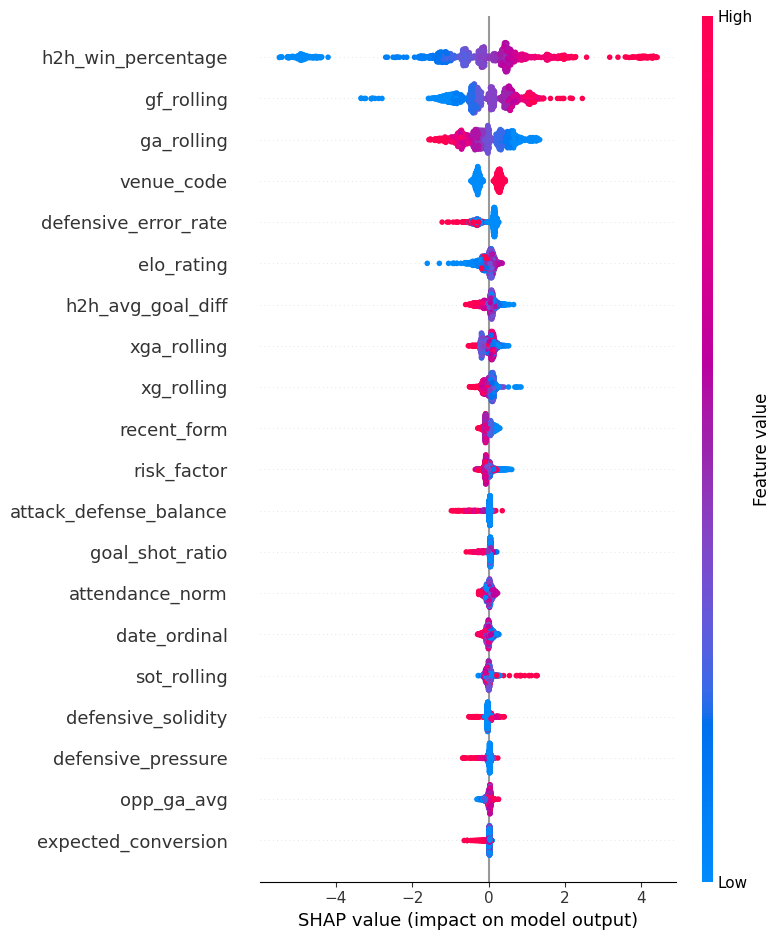

In [ ]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

# Ensure 'round' column exists or create a proxy
if 'round' not in matches_rolling.columns:
    matches_rolling['round'] = matches_rolling.groupby('season')['date'].rank(method='dense').astype(int)

# Columns for rolling averages
cols = [
    "gf", "ga", "sh", "sot", "xg", "xga", "poss", "xa", "kp",
    "prgp", "prgc", "ppa", "tkl+int", "blocks", "touches",
    "Total_Passes_cmp", "Total_Passes_att"
]

# Compute rolling averages across all teams, ordered by date
matches_rolling = matches_rolling.sort_values('date')
for col in cols:
    if col in matches_rolling.columns:
        matches_rolling[f'{col}_rolling'] = matches_rolling.groupby('team', group_keys=False)[col]\
            .rolling(window=4, min_periods=1).mean().reset_index(0, drop=True)

# Fix train-test split by season
def season_train_test_split(df, train_ratio=0.8):
    """
    Splits dataset into train and test sets by season.
    """
    df = df.sort_values(['season', 'date'])

    train_data = df.groupby('season', group_keys=False, observed=True).apply(
        lambda x: x.iloc[:int(len(x) * train_ratio)]
    ).reset_index(drop=True)

    test_data = df.groupby('season', group_keys=False, observed=True).apply(
        lambda x: x.iloc[int(len(x) * train_ratio):]
    ).reset_index(drop=True)

    return train_data, test_data

# Perform train-test split
X_train, X_test = season_train_test_split(matches_rolling)

# Prepare features and target
features = [
    'date_ordinal', 'venue_code', 'opp_code',
    'gf_rolling', 'ga_rolling', 'sot_rolling',
    'xg_rolling', 'xga_rolling',
     'h2h_avg_goal_diff', 'h2h_win_percentage',
    'elo_rating', 'defensive_error_rate',
    'recent_form',
    'conversion_efficiency', 'defensive_solidity', 'form_trend', 'attendance_norm',
    'attack_defense_balance', 'performance_pressure', 'expected_conversion',
    'conversion_gap', 'composite_form', 'defensive_pressure',
    'risk_factor', 'opp_ga_avg', 'goal_shot_ratio'
]

# Ensure features exist in the DataFrame
features = [f for f in features if f in matches_rolling.columns]

# Prepare X and y
y_train = X_train['target']
y_test = X_test['target']

# Fit scaler on training data and transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled = scaler.transform(X_test[features])

# Model Training
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        colsample_bytree=0.9,
        learning_rate=0.07,
        max_depth=3,
        n_estimators=400,
        subsample=1.0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        min_samples_leaf=3,
        min_samples_split=2
    ),
    'LogisticRegression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    )
}

# Results storage
results = {}
feature_impcaortance = {}

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = classification_report(y_test, y_pred)

    # Get feature importance
    if hasattr(model, 'feature_importances_'):
        feature_importance[name] = model.feature_importances_
    elif hasattr(model, 'coef_'):
        feature_importance[name] = np.abs(model.coef_[0])

# Print results
print("\nModel Performance:")
for name, report in results.items():
    print(f"\n{name} Report:\n{report}")

# Print feature importance
print("\nFeature Importance:")
for name, importance in feature_importance.items():
    feature_imp_df = pd.DataFrame({
        'Feature': features[:len(importance)],
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    print(f"\n{name} Top Features:\n", feature_imp_df.head(15))

# Optional: SHAP Analysis (if using XGBoost)
if 'XGBoost' in models:
    explainer = shap.Explainer(models['XGBoost'])
    shap_values = explainer(X_test_scaled)
    shap.summary_plot(shap_values, X_test_scaled, feature_names=features)



In [ ]:
# Create a dictionary of predictions from different models
model_predictions = {
    'XGBoost': y_pred_xgb,
    'RandomForest': y_pred_rf,
    'LogisticRegression': y_pred_lr,
}

# Get the test set details from matches_rolling
test_matches_original = matches_rolling.iloc[split_index:].copy()

# Loop through each model, add the predictions, filter misclassified matches, and save to CSV
for model_name, preds in model_predictions.items():
    # Create a fresh copy for each model so that the 'predicted' column does not carry over
    test_matches_model = test_matches_original.copy()
    test_matches_model['predicted'] = preds
    misclassified = test_matches_model[test_matches_model['target'] != test_matches_model['predicted']]

    # Define a filename based on the model name
    csv_filename = f'misclassified_{model_name}.csv'
    misclassified.to_csv(csv_filename, index=False)
    print(f"Saved misclassified matches for {model_name} to {csv_filename}")


Saved misclassified matches for XGBoost to misclassified_XGBoost.csv
Saved misclassified matches for RandomForest to misclassified_RandomForest.csv
Saved misclassified matches for LogisticRegression to misclassified_LogisticRegression.csv
Saved misclassified matches for PoissonRegression to misclassified_PoissonRegression.csv
Saved misclassified matches for MLP to misclassified_MLP.csv
Saved misclassified matches for LSTM to misclassified_LSTM.csv


In [ ]:
import pandas as pd
import numpy as np


# Modified prepare_new_matches function with additional checks
def prepare_new_matches(new_matches, matches_rolling, scaler, features):
    """
    Prepare new matches data with additional validation
    """
    pred_matches = new_matches.copy()


    # Print team mapping check
    print("\nChecking team mappings...")
    for team in pred_matches['team'].unique():
        matches = matches_rolling[matches_rolling['team'] == team]
        if len(matches) == 0:
            print(f"Warning: No data found for team {team}")
        else:
            print(f"Found {len(matches)} matches for {team}")

    # Encode categorical variables
    venue_mapping = {'Home': 1, 'Away': 0}
    pred_matches['venue_code'] = pred_matches['venue'].map(venue_mapping)

    # Build opponent mapping
    all_teams = set(matches_rolling['team'].unique()) | set(matches_rolling['opponent'].unique())
    opp_mapping = {team: i for i, team in enumerate(all_teams)}

    # Verify opponent mapping
    for opp in pred_matches['opponent']:
        if opp not in opp_mapping:
            print(f"Warning: No opponent code found for {opp}")

    pred_matches['opp_code'] = pred_matches['opponent'].map(opp_mapping)

    # Time and day processing
    pred_matches['hour'] = pred_matches['time'].str.split(':').str[0].astype(int)
    day_mapping = {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7}
    pred_matches['day_code'] = pred_matches['day'].map(day_mapping)

    # Get latest statistics with verification
    latest_stats = matches_rolling.groupby('team').last().reset_index()

    # Print sample of rolling averages for verification
    print("\nSample of rolling averages:")
    print(latest_stats[['team', 'gf_rolling', 'ga_rolling', 'xg_rolling']].head())

    # Merge statistics
    col_extras = [col for col in features if col not in ['venue_code', 'opp_code', 'hour', 'day_code']]
    pred_matches = pred_matches.merge(
        latest_stats[['team'] + col_extras],
        on='team',
        how='left'
    )

    # Check for missing values
    missing_cols = pred_matches.columns[pred_matches.isna().any()].tolist()
    if missing_cols:
        print(f"\nWarning: Missing values in columns: {missing_cols}")

    pred_matches = pred_matches.fillna(0)

    # Prepare features in correct order
    X_pred = pred_matches[features].copy()

    # Print feature ranges before scaling
    print("\nFeature ranges before scaling:")
    print(X_pred.describe().round(2))

    # Scale
    X_pred_scaled = scaler.transform(X_pred)

    # Print feature ranges after scaling
    print("\nFeature ranges after scaling:")
    print(pd.DataFrame(X_pred_scaled, columns=features).describe().round(2))

    return X_pred_scaled, pred_matches

def predict_matches(X_pred_scaled, pred_matches, stacking_model):
    """
    Make predictions and format results using the stacking model
    """
    y_proba = stacking_model.predict_proba(X_pred_scaled)  # [loss_prob, draw_prob, win_prob] for each row

    results = pd.DataFrame({
        'Date': pred_matches['date'],
        'Time': pred_matches['time'],
        'Home Team': pred_matches['team'],
        'Away Team': pred_matches['opponent'],
        'Venue': pred_matches['venue'],
        'Loss Prob': [f"{prob[0]:.2%}" for prob in y_proba],
        'Draw Prob': [f"{prob[1]:.2%}" for prob in y_proba],
        'Win Prob': [f"{prob[2]:.2%}" for prob in y_proba],
        'Predicted Result': [
            'Win' if np.argmax(prob) == 2 else
            'Draw' if np.argmax(prob) == 1 else 'Loss'
            for prob in y_proba
        ]
    })

    # Sort predictions chronologically
    results = results.sort_values(['Date', 'Time'])
    return results

# --------------------------------------------------------------------
# MAKE PREDICTIONS WITH THE UPDATED FIXTURES
# (Assumes matches_rolling, scaler, features, and stacking_model are defined)
# --------------------------------------------------------------------
X_pred_scaled, pred_matches = prepare_new_matches(new_matches, matches_rolling, scaler, features)
results = predict_matches(X_pred_scaled, pred_matches, stacking_model)

print("\nFinal Predictions:")
print(results.to_string(index=False))


In [ ]:
# ------ TWEAK 2: CORRECT NEW_MATCHES TEAM NAMES TO MATCH TRAINING DATA FORMAT ------
def prepare_new_matches(new_matches, matches_rolling, scaler, features):
    pred_matches = new_matches.copy()

    # Standardize team names to lowercase and apply corrections
    team_name_corrections = {
        "Nott'ham Forest": "nottingham forest",
        "Newcastle Utd": "newcastle united",
        "Wolves": "wolverhampton wanderers",
        "Manchester Utd": "manchester united",
        "Brighton": "brighton and hove albion",
        "West Ham": "west ham united",
        "Tottenham": "tottenham hotspur"
    }

    pred_matches['team'] = (
        pred_matches['team']
        .replace(team_name_corrections)
        .str.strip()
        .str.lower()
    )
    pred_matches['opponent'] = (
        pred_matches['opponent']
        .replace(team_name_corrections)
        .str.strip()
        .str.lower()
    )

    # Verify team mappings
    print("\nChecking team mappings...")
    for team in pred_matches['team'].unique():
        matches = matches_rolling[matches_rolling['team'] == team]
        if len(matches) == 0:
            print(f"Warning: No data found for team '{team}'")
        else:
            print(f"Found {len(matches)} matches for '{team}'")

    # Encode venue
    venue_mapping = {'Home': 1, 'Away': 0}
    pred_matches['venue_code'] = pred_matches['venue'].map(venue_mapping)

    # Build opponent mapping from training data
    all_teams = set(matches_rolling['team'].unique()) | set(matches_rolling['opponent'].unique())
    opp_mapping = {team: idx for idx, team in enumerate(sorted(all_teams))}
    pred_matches['opp_code'] = pred_matches['opponent'].map(opp_mapping)

    # Check for missing opponent mappings
    missing_opps = pred_matches[pred_matches['opp_code'].isna()]['opponent'].unique()
    if len(missing_opps) > 0:
        print(f"Warning: The following opponents have no mapping: {missing_opps}")

    # Time and day processing
    pred_matches['hour'] = pred_matches['time'].str.split(':').str[0].astype(int)
    day_mapping = {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7}
    pred_matches['day_code'] = pred_matches['day'].map(day_mapping)

    # Get latest statistics
    latest_stats = matches_rolling.groupby('team').last().reset_index()

    # Merge rolling features
    col_extras = [col for col in features if col not in ['venue_code','opp_code','hour','day_code']]
    pred_matches = pred_matches.merge(
        latest_stats[['team'] + col_extras],
        on='team',
        how='left'
    )

    # Fill missing values with mean
    numeric_cols = pred_matches.select_dtypes(include=[np.number]).columns
    pred_matches[numeric_cols] = pred_matches[numeric_cols].fillna(pred_matches[numeric_cols].mean())

    # Prepare features in correct order
    X_pred = pred_matches[features].copy()
    X_pred_scaled = scaler.transform(X_pred)

    return X_pred_scaled, pred_matches

# --------------------------------------------------------------------
# UPDATED new_matches DATAFRAME FOR FEB 1–3, 2025
# --------------------------------------------------------------------
new_matches = pd.DataFrame({
   'date': [
       '2025-02-01', '2025-02-01', '2025-02-01', '2025-02-01', '2025-02-01', '2025-02-01',
       '2025-02-02', '2025-02-02', '2025-02-02', '2025-02-03'
   ],
   'time': [
       '12:30', '15:00', '15:00', '15:00', '15:00', '17:30',
       '14:00', '14:00', '16:30', '20:00'
   ],
   'team': [
       "Nott'ham Forest", 'Ipswich Town', 'Everton', 'Newcastle Utd', 'Bournemouth', 'Wolves',
       'Brentford', 'Manchester Utd', 'Arsenal', 'Chelsea'
   ],
   'opponent': [
       'Brighton', 'Southampton', 'Leicester City', 'Fulham', 'Liverpool', 'Aston Villa',
       'Tottenham', 'Crystal Palace', 'Manchester City', 'West Ham'
   ],
   'venue': ['Home'] * 10,
   'day': [
       'Sat', 'Sat', 'Sat', 'Sat', 'Sat', 'Sat',
       'Sun', 'Sun', 'Sun', 'Mon'
   ]
})

# --------------------------------------------------------------------
# MAKE PREDICTIONS WITH THE UPDATED FIXTURES
# --------------------------------------------------------------------
# (Assume X_train_scaled, y_train, scaler, and features are already defined)
# Example usage:
# X_pred_scaled, pred_matches = prepare_new_matches(new_matches, matches_rolling, scaler, features)
# results = predict_matches(X_pred_scaled, pred_matches, model)